# Support Vector Machines for Breast Cancer Classification

This project applies **Support Vector Machines (SVM)** for classifying breast cancer as malignant or benign using the **Breast Cancer Wisconsin dataset**.  
Two models are evaluated:
- Linear SVM
- RBF (Radial Basis Function) Kernel SVM

The project also uses PCA to visualize decision boundaries in 2D space.

### Objectives
- Load and preprocess the breast cancer dataset
- Train and evaluate Linear and RBF SVM models
- Compare performance metrics
- Visualize decision boundaries using PCA


## Import Libraries

In [4]:
# 1. Imports
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Plotting style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)


In [7]:
# 2. Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (569, 30)
Target vector shape: (569,)


In [10]:
# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [15]:
# 5. Linear SVM
linear_svm = SVC(kernel='linear', C=1)
linear_svm.fit(X_train_scaled, y_train)
y_pred_linear = linear_svm.predict(X_test_scaled)


In [17]:
# 6. RBF (Non-Linear) SVM
rbf_svm = SVC(kernel='rbf', C=1, gamma='scale')
rbf_svm.fit(X_train_scaled, y_train)
y_pred_rbf = rbf_svm.predict(X_test_scaled)


In [19]:
# 7. Evaluation
print("Linear SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print(classification_report(y_test, y_pred_linear))

print("RBF SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print(classification_report(y_test, y_pred_rbf))


Linear SVM
Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

RBF SVM
Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



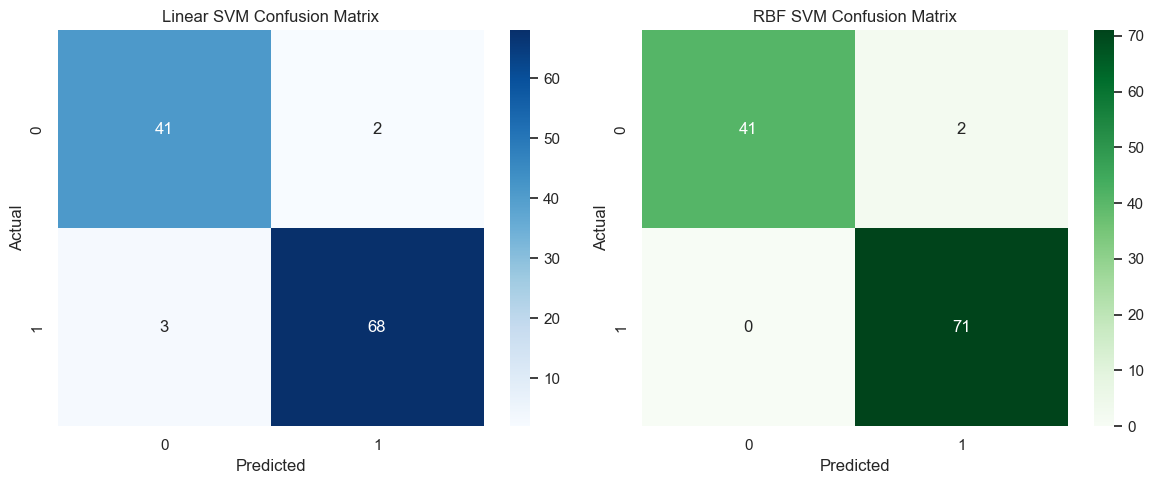

In [21]:
# 8. Confusion Matrix
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_linear), annot=True, fmt='d', cmap='Blues')
plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_rbf), annot=True, fmt='d', cmap='Greens')
plt.title("RBF SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


In [23]:
# 9. PCA Reduction
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Fit models again on PCA-reduced data
linear_pca = SVC(kernel='linear', C=1)
linear_pca.fit(X_train_pca, y_train)

rbf_pca = SVC(kernel='rbf', C=1, gamma='scale')
rbf_pca.fit(X_train_pca, y_train)


,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


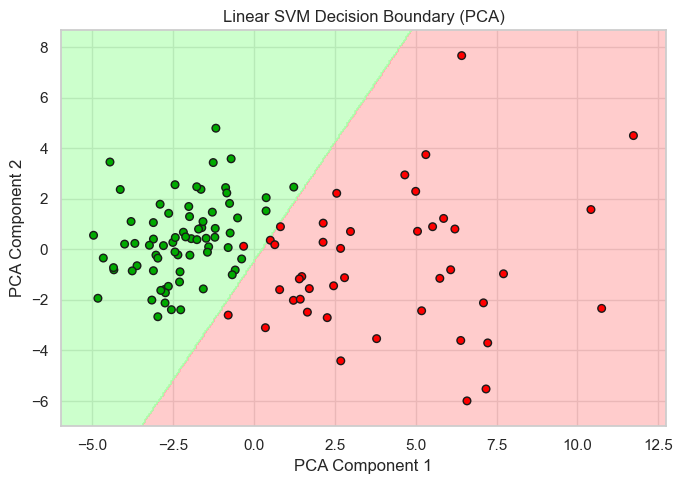

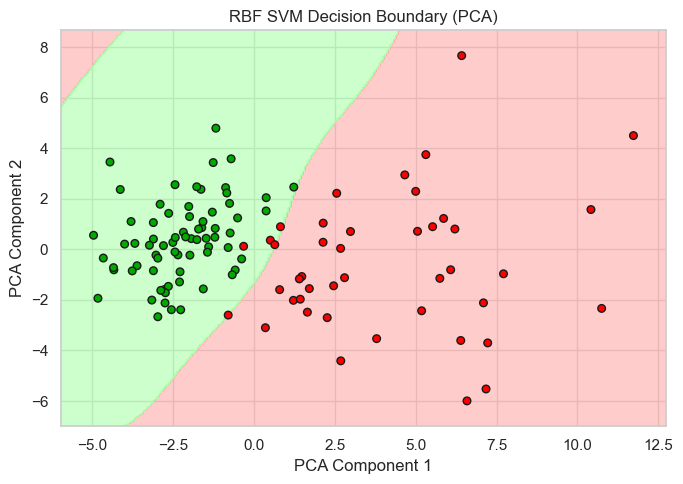

In [25]:
# Helper function to plot decision boundary
def plot_decision_boundary(model, X, y, title):
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ['#FF0000', '#00AA00']

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(cmap_bold), edgecolor='k', s=30)
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.tight_layout()
    plt.show()

# Plot decision boundaries
plot_decision_boundary(linear_pca, X_test_pca, y_test, "Linear SVM Decision Boundary (PCA)")
plot_decision_boundary(rbf_pca, X_test_pca, y_test, "RBF SVM Decision Boundary (PCA)")


# Summary

This project applied Support Vector Machines (SVM) to classify breast cancer as malignant or benign.  
Both Linear and RBF kernel SVM models were trained and evaluated.  
The RBF model achieved slightly better accuracy than the linear model.  
Confusion matrices provided insights into the classification performance, and PCA visualization allowed for better understanding of the decision boundaries.

### Key Observations
- Feature scaling significantly improved model performance.
- The RBF kernel performed better for this dataset.
- PCA is a useful tool for visualizing high-dimensional data and model decision boundaries.
